# CORINE Land Cover — occupation du sol par commune

**Fichier** : `clc_etat_com_n3.csv` (79 Mo) · **Source** : SDES / Copernicus Land Monitoring Service
**Contenu** : pour chaque commune et chaque millésime, la surface (ha) de chacun des **44 postes** de la nomenclature CORINE **niveau 3**.

Ce jeu répond à une seule question dans notre projet : **de quoi une commune est-elle faite ?** C'est le « combustible » que le FWI, purement météorologique, ne connaît pas.

---

### Ce que ce notebook doit établir

| # | Question | Pourquoi |
|---|---|---|
| 1 | Combien de millésimes, et lesquels retenir ? | Trois années existent en **deux versions** |
| 2 | Les surfaces sont-elles cohérentes ? | Leur somme doit valoir la superficie communale |
| 3 | **La clé de jointure est-elle compatible ?** | CORINE est en **COG 2010**, notre référentiel en **COG 2026** |

## 1. Chargement

⚠️ **Le fichier a quatre lignes d'en-tête**, pas une :

| ligne | contenu | exemple |
|---|---|---|
| 1 | libellés lisibles | `Superficie du poste 311 - Forêts de feuillus (en ha)` |
| 2 | types de données | `cog_commune_2010`, `annee`, `nombre` |
| 3 | unités | `ha` |
| 4 | **codes machine** | `CLC_311` |

On prend la ligne 4 comme noms de colonnes (courts et stables) et on garde la ligne 1 comme dictionnaire de libellés.

In [ ]:
# ── enregistrement automatique des figures ──
# chaque plt.show() écrit aussi un PNG dans figures/data-corine/
import sys
from pathlib import Path

for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "src" / "tvfed").is_dir():
        sys.path.insert(0, str(_p / "src"))
        break

from tvfed.figures import activer

activer("data-corine")

In [1]:
import pandas as pd, numpy as np, csv
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def _trouve(sc):
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / sc).exists():
            return p / sc
    raise FileNotFoundError(f"'{sc}' introuvable depuis {Path.cwd()}")

CLC_CSV = _trouve("data/corine/clc_etat_com_n3.csv")

INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
BLEU, ORANGE, ROUGE, VERT = "#2a78d6", "#eb6834", "#e34948", "#1baf7a"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.size": 9, "axes.edgecolor": "#c3c2b7", "text.color": INK})

# Nomenclature CORINE — hiérarchie à 3 niveaux, le 1er chiffre porte le grand type
NIV1 = {"1": "Territoires artificialisés", "2": "Territoires agricoles",
        "3": "Forêts et milieux semi-naturels", "4": "Zones humides", "5": "Surfaces en eau"}
COUL_N1 = {"1": "#c3c2b7", "2": "#eda100", "3": "#1baf7a", "4": "#86b6ef", "5": "#2a78d6"}

print(f"📂 {CLC_CSV.name} — {CLC_CSV.stat().st_size/1e6:.0f} Mo")

📂 clc_etat_com_n3.csv — 79 Mo


In [2]:
"""Chargement — le fichier a QUATRE lignes d'en-tête, pas une."""
# ligne 1 = libellés lisibles · 2 = types · 3 = unités · 4 = codes machine (CLC_311…)
# On garde les codes comme noms de colonnes et on met les libellés de côté.
with open(CLC_CSV, encoding="utf-8") as fh:
    r = csv.reader(fh, delimiter=";")
    libelles, types, unites, codes = [next(r) for _ in range(4)]

# "Superficie du poste 311 - Forêts de feuillus (en ha)" → "Forêts de feuillus"
LABEL = {c: (l.split(" - ", 1)[-1].replace(" (en ha)", "") if " - " in l else l)
         for c, l in zip(codes, libelles)}

CLC = pd.read_csv(CLC_CSV, sep=";", skiprows=[1, 2, 3], header=0, names=codes,
                  dtype={"NUM_COM": str}, low_memory=False)
POSTES = [c for c in CLC.columns if c.startswith("CLC_")]
CLC[POSTES] = CLC[POSTES].apply(pd.to_numeric, errors="coerce")
CLC["ANNEE"] = CLC.ANNEE.astype(int)

print(f"{len(CLC):,} lignes × {CLC.shape[1]} colonnes")
print(f"communes : {CLC.NUM_COM.nunique():,}   ·   postes CLC niveau 3 : {len(POSTES)}")
print(f"unité : {unites[3]}   ·   clé : {types[0]}\n")
print("Millésimes disponibles :")
print(CLC.groupby(["ANNEE", "base"]).size().to_string())

286,048 lignes × 47 colonnes
communes : 35,756   ·   postes CLC niveau 3 : 44
unité : ha   ·   clé : cog_commune_2010

Millésimes disponibles :
ANNEE  base            
1990   CLC 1990            35756
2000   CLC 2000            35756
       CLC 2000 révisée    35756
2006   CLC 2006            35756
       CLC 2006 révisée    35756
2012   CLC 2012            35756
       CLC 2012 révisée    35756
2018   CLC 2018            35756


## 2. Audit

Le piège principal : **2000, 2006 et 2012 existent en deux versions**, normale et « révisée ». Ce ne sont pas des doublons à supprimer aveuglément — la révision corrige la version initiale. On mesure l'écart avant de choisir.

In [3]:
"""Audit — la duplication « révisée », l'intégrité des surfaces, les manquants."""
print("1. LA DUPLICATION « RÉVISÉE »")
print("   2000, 2006 et 2012 existent en DEUX versions. Ce ne sont pas des doublons")
print("   à supprimer : la version révisée corrige la précédente.\n")
paires = CLC.groupby("ANNEE").base.nunique()
print(paires.to_string())

# de combien les deux versions diffèrent-elles ?
for an in sorted(CLC[CLC.ANNEE.map(paires) > 1].ANNEE.unique()):
    a, b = sorted(CLC[CLC.ANNEE == an].base.unique())
    va = CLC[(CLC.ANNEE == an) & (CLC.base == a)].set_index("NUM_COM")[POSTES]
    vb = CLC[(CLC.ANNEE == an) & (CLC.base == b)].set_index("NUM_COM")[POSTES]
    vb = vb.reindex(va.index)
    diff = (va - vb).abs().sum(axis=1)
    print(f"   {an} : {(diff > .01).sum():,} communes diffèrent entre « {a} » et « {b} » "
          f"({(diff > .01).mean():.1%})")

# ── choix : on garde la version révisée quand elle existe ──
CLC["rev"] = CLC.base.str.contains("révisée")
garde = (CLC.sort_values(["NUM_COM", "ANNEE", "rev"])
            .drop_duplicates(["NUM_COM", "ANNEE"], keep="last"))
print(f"\n   → on conserve la version révisée quand elle existe : "
      f"{len(CLC):,} → {len(garde):,} lignes")

print("\n2. INTÉGRITÉ DES SURFACES")
tot = garde[POSTES].sum(axis=1)
print(f"   somme des 44 postes = superficie communale")
print(f"   min {tot.min():,.0f} ha · médiane {tot.median():,.0f} ha · max {tot.max():,.0f} ha")
print(f"   communes à surface nulle : {(tot == 0).sum()}")
# la superficie doit être stable d'un millésime à l'autre pour une même commune
var = garde.assign(tot=tot).groupby("NUM_COM").tot.agg(lambda s: s.max() - s.min())
print(f"   écart max de superficie entre millésimes, par commune :")
print(f"      médiane {var.median():.3f} ha · 99e centile {var.quantile(.99):.2f} ha "
      f"· max {var.max():.1f} ha")

print("\n3. VALEURS MANQUANTES")
nan_postes = garde[POSTES].isna().sum().sum()
print(f"   cellules NaN dans les 44 postes : {nan_postes}")
print(f"   → un poste absent d'une commune vaut 0, pas NaN : rien à imputer.")

CLC_N = garde.drop(columns=["rev"]).reset_index(drop=True)

1. LA DUPLICATION « RÉVISÉE »
   2000, 2006 et 2012 existent en DEUX versions. Ce ne sont pas des doublons
   à supprimer : la version révisée corrige la précédente.

ANNEE
1990    1
2000    2
2006    2
2012    2
2018    1
   2000 : 27,797 communes diffèrent entre « CLC 2000 » et « CLC 2000 révisée » (77.7%)
   2006 : 25,118 communes diffèrent entre « CLC 2006 » et « CLC 2006 révisée » (70.2%)
   2012 : 21,461 communes diffèrent entre « CLC 2012 » et « CLC 2012 révisée » (60.0%)

   → on conserve la version révisée quand elle existe : 286,048 → 178,780 lignes

2. INTÉGRITÉ DES SURFACES
   somme des 44 postes = superficie communale
   min 3 ha · médiane 1,085 ha · max 75,780 ha
   communes à surface nulle : 0
   écart max de superficie entre millésimes, par commune :
      médiane 0.000 ha · 99e centile 0.00 ha · max 0.0 ha

3. VALEURS MANQUANTES
   cellules NaN dans les 44 postes : 0
   → un poste absent d'une commune vaut 0, pas NaN : rien à imputer.


## 3. La nomenclature : 44 postes, 5 grandes classes

CORINE est **hiérarchique** : le premier chiffre du code donne la classe de niveau 1.

| Code | Classe |
|---|---|
| 1xx | Territoires artificialisés |
| 2xx | Territoires agricoles |
| 3xx | Forêts et milieux semi-naturels |
| 4xx | Zones humides |
| 5xx | Surfaces en eau |

C'est ce qui rend le jeu utilisable à plusieurs granularités : on peut agréger au niveau 1 pour une vue d'ensemble, ou garder le niveau 3 pour distinguer un maquis d'une forêt de conifères.

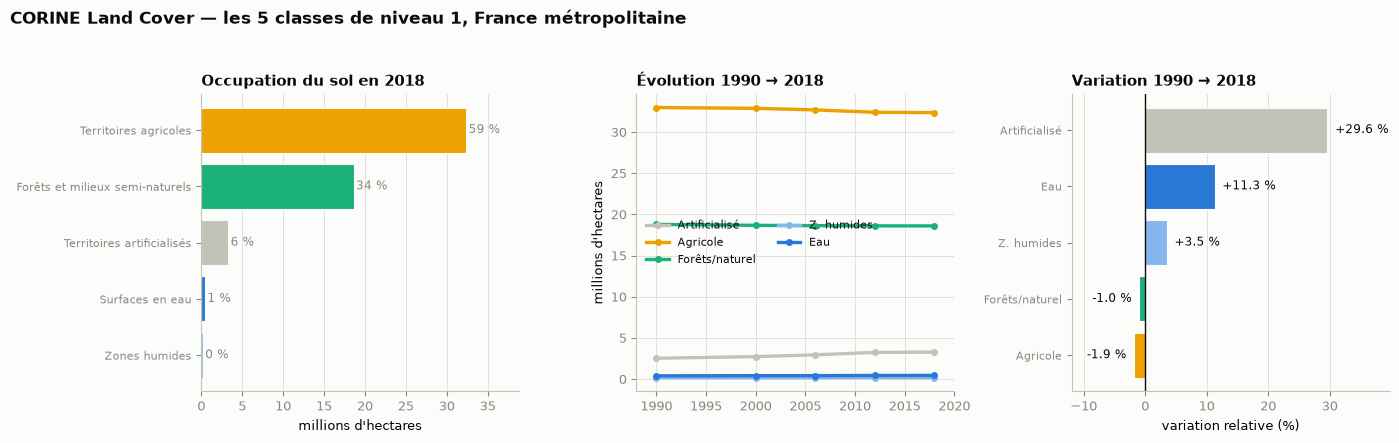

Surface totale 2018 : 54.9 M ha
   Territoires agricoles              32.37 M ha  (59.0 %)  -1.9 % depuis 1990
   Forêts et milieux semi-naturels    18.61 M ha  (33.9 %)  -1.0 % depuis 1990
   Territoires artificialisés          3.28 M ha  ( 6.0 %)  +29.6 % depuis 1990
   Surfaces en eau                     0.45 M ha  ( 0.8 %)  +11.3 % depuis 1990
   Zones humides                       0.18 M ha  ( 0.3 %)  +3.5 % depuis 1990


In [4]:
"""FIG 1 — La nomenclature : 44 postes qui se rangent en 5 grandes classes."""
n1 = pd.Series({p: p.split("_")[1][0] for p in POSTES})          # CLC_311 → "3"
NAT = CLC_N.groupby("ANNEE")[POSTES].sum()                        # France entière, par millésime
nat_n1 = NAT.T.groupby(n1).sum().T                                # → 5 classes

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

der = nat_n1.iloc[-1].sort_values(ascending=False)
ax[0].barh([NIV1[k] for k in der.index][::-1], der.values[::-1] / 1e6,
           color=[COUL_N1[k] for k in der.index][::-1], edgecolor="#fcfcfb", linewidth=.8)
for i, v in enumerate(der.values[::-1]):
    ax[0].text(v / 1e6 + .3, i, f"{100*v/der.sum():.0f} %", va="center", fontsize=8.5, color=MUTED)
ax[0].set_title(f"Occupation du sol en {NAT.index[-1]}", fontsize=10.5, weight="bold", loc="left")
ax[0].set_xlabel("millions d'hectares"); ax[0].tick_params(axis="y", labelsize=8)
ax[0].set_xlim(0, der.max() / 1e6 * 1.2)

# libellés courts : « Territoires… » désignait 2 classes différentes
COURT = {"1": "Artificialisé", "2": "Agricole", "3": "Forêts/naturel",
         "4": "Z. humides", "5": "Eau"}
for k in nat_n1.columns:
    ax[1].plot(nat_n1.index, nat_n1[k] / 1e6, color=COUL_N1[k], lw=2.4, marker="o", ms=4,
               label=COURT[k])
ax[1].set_title("Évolution 1990 → 2018", fontsize=10.5, weight="bold", loc="left")
ax[1].set_ylabel("millions d'hectares"); ax[1].set_xlim(1988, 2020)
ax[1].legend(frameon=False, fontsize=8, ncol=2, loc="center left")

ecart = ((nat_n1.iloc[-1] - nat_n1.iloc[0]) / nat_n1.iloc[0] * 100).sort_values()
ax[2].barh([COURT[k] for k in ecart.index], ecart.values,
           color=[COUL_N1[k] for k in ecart.index], edgecolor="#fcfcfb", linewidth=.8)
ax[2].axvline(0, color=INK, lw=1)
marge = (ecart.max() - ecart.min()) * .04       # décalage proportionnel à l'échelle
for i, v in enumerate(ecart.values):
    ax[2].text(v + (marge if v >= 0 else -marge), i, f"{v:+.1f} %", va="center",
               ha="left" if v >= 0 else "right", fontsize=8.5)
ax[2].set_title(f"Variation {NAT.index[0]} → {NAT.index[-1]}", fontsize=10.5, weight="bold", loc="left")
ax[2].set_xlabel("variation relative (%)")
ax[2].tick_params(axis="y", labelsize=8)
ax[2].set_xlim(ecart.min() - 8 * marge, ecart.max() + 8 * marge)

for a in ax:
    a.grid(axis="x", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
ax[1].grid(axis="y", color=GRID, lw=.7)
fig.suptitle("CORINE Land Cover — les 5 classes de niveau 1, France métropolitaine",
             fontsize=12.5, weight="bold", x=.005, ha="left", y=1.04)
plt.tight_layout(); plt.show()

print(f"Surface totale {NAT.index[-1]} : {der.sum()/1e6:.1f} M ha")
for k in der.index:
    print(f"   {NIV1[k]:34s} {der[k]/1e6:5.2f} M ha  ({100*der[k]/der.sum():4.1f} %)  "
          f"{ecart[k]:+.1f} % depuis {NAT.index[0]}")

## 4. Le combustible

Sur les 44 postes, **huit** décrivent de la végétation qui brûle. Le poste **323 « Végétation sclérophylle »** est le maquis et la garrigue méditerranéens : c'est le poste le plus directement lié au risque incendie du périmètre v1.

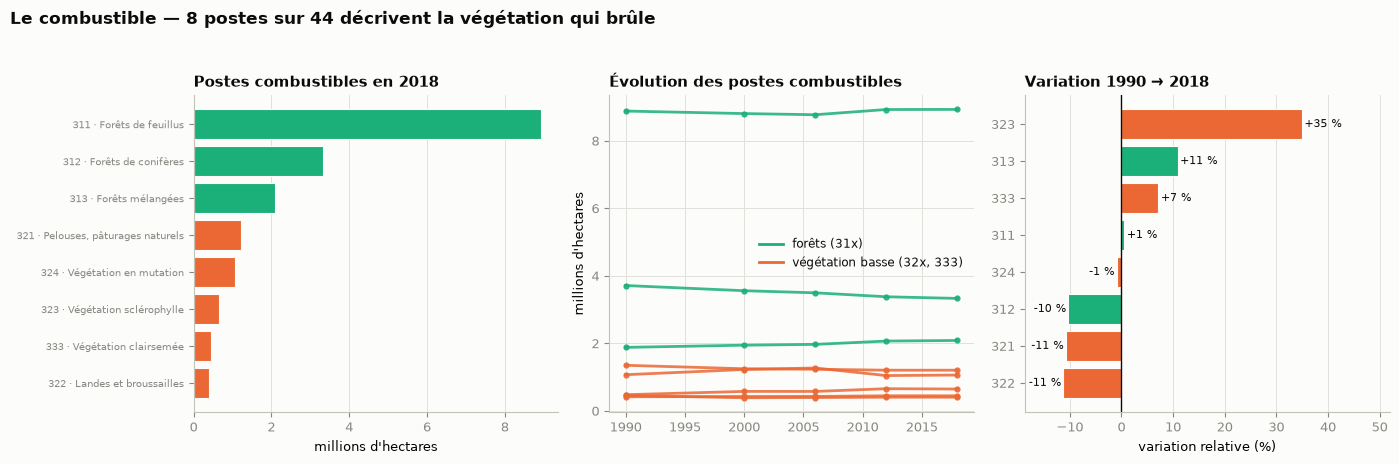

Surface combustible 2018 : 18.12 M ha (33 % du territoire)

⭐ Le poste 323 « Végétation sclérophylle » = maquis et garrigue.
   648 k ha, presque exclusivement méditerranéens :
   c'est LE poste à surveiller pour le risque incendie du périmètre v1.


In [5]:
"""FIG 2 — Les postes qui portent le combustible."""
# Sur les 44 postes, ceux-ci décrivent de la végétation qui brûle.
COMBUSTIBLE = {
    "CLC_311": "Forêts de feuillus",        "CLC_312": "Forêts de conifères",
    "CLC_313": "Forêts mélangées",          "CLC_321": "Pelouses, pâturages naturels",
    "CLC_322": "Landes et broussailles",    "CLC_323": "Végétation sclérophylle",
    "CLC_324": "Végétation en mutation",    "CLC_333": "Végétation clairsemée",
}
COMB = [c for c in COMBUSTIBLE if c in POSTES]

fig, ax = plt.subplots(1, 3, figsize=(14, 4.4))

der_c = NAT.iloc[-1][COMB].sort_values()
cols = [VERT if c.startswith("CLC_31") else ORANGE for c in der_c.index]
ax[0].barh([f"{c.split('_')[1]} · {COMBUSTIBLE[c]}" for c in der_c.index], der_c.values / 1e6,
           color=cols, edgecolor="#fcfcfb", linewidth=.8)
ax[0].set_title(f"Postes combustibles en {NAT.index[-1]}", fontsize=10.5, weight="bold", loc="left")
ax[0].set_xlabel("millions d'hectares"); ax[0].tick_params(axis="y", labelsize=7.5)

for c in COMB:
    ax[1].plot(NAT.index, NAT[c] / 1e6, lw=2, marker="o", ms=3.5,
               color=VERT if c.startswith("CLC_31") else ORANGE, alpha=.85)
ax[1].set_title("Évolution des postes combustibles", fontsize=10.5, weight="bold", loc="left")
ax[1].set_ylabel("millions d'hectares")
ax[1].plot([], [], color=VERT, lw=2, label="forêts (31x)")
ax[1].plot([], [], color=ORANGE, lw=2, label="végétation basse (32x, 333)")
ax[1].legend(frameon=False, fontsize=8.5)

ec = ((NAT.iloc[-1][COMB] - NAT.iloc[0][COMB]) / NAT.iloc[0][COMB] * 100).sort_values()
ax[2].barh([c.split("_")[1] for c in ec.index], ec.values,
           color=[VERT if c.startswith("CLC_31") else ORANGE for c in ec.index],
           edgecolor="#fcfcfb", linewidth=.8)
ax[2].axvline(0, color=INK, lw=1)
for i, v in enumerate(ec.values):
    ax[2].text(v + (.5 if v >= 0 else -.5), i, f"{v:+.0f} %", va="center",
               ha="left" if v >= 0 else "right", fontsize=8)
ax[2].set_title(f"Variation {NAT.index[0]} → {NAT.index[-1]}", fontsize=10.5, weight="bold", loc="left")
ax[2].set_xlabel("variation relative (%)")
ax[2].set_xlim(ec.min() * 1.4 - 3, ec.max() * 1.4 + 3)

for a in ax:
    a.grid(axis="x", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
ax[1].grid(axis="y", color=GRID, lw=.7)
fig.suptitle("Le combustible — 8 postes sur 44 décrivent la végétation qui brûle",
             fontsize=12.5, weight="bold", x=.005, ha="left", y=1.04)
plt.tight_layout(); plt.show()

tot_comb = NAT.iloc[-1][COMB].sum()
print(f"Surface combustible {NAT.index[-1]} : {tot_comb/1e6:.2f} M ha "
      f"({100*tot_comb/NAT.iloc[-1].sum():.0f} % du territoire)")
print(f"\n⭐ Le poste 323 « Végétation sclérophylle » = maquis et garrigue.")
print(f"   {NAT.iloc[-1]['CLC_323']/1e3:,.0f} k ha, presque exclusivement méditerranéens :")
print(f"   c'est LE poste à surveiller pour le risque incendie du périmètre v1.")

## 5. Profil communal et jointure

Deux choses : à quoi ressemblent les communes une à une, et **la clé de jointure tient-elle** ?

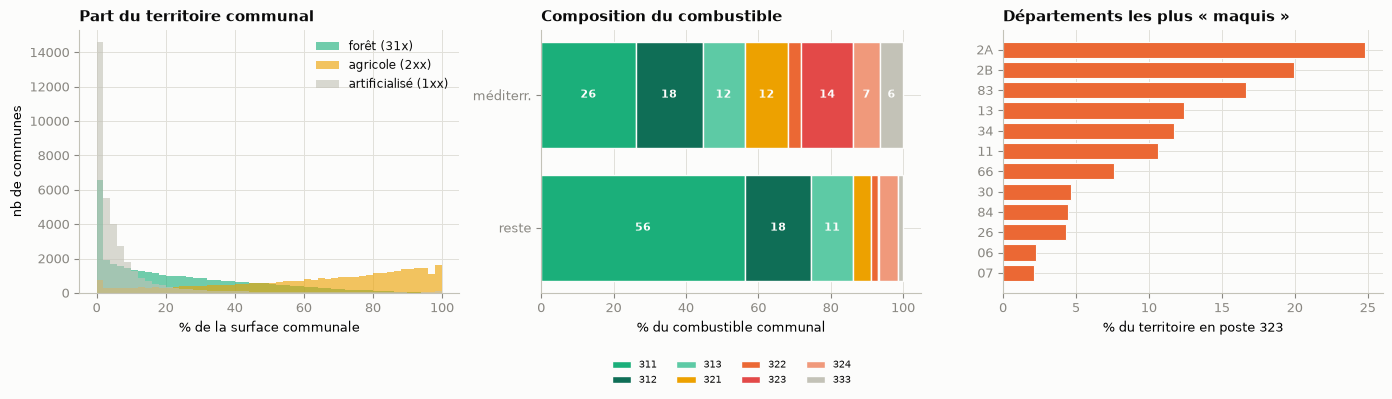

Communes 100 % agricoles : 1,263
Communes sans aucune forêt : 3,992
Communes à plus de 50 % de forêt : 5,129
Communes avec du maquis (323 > 0) : 1,477 (4.1%)  → le poste est bien régional


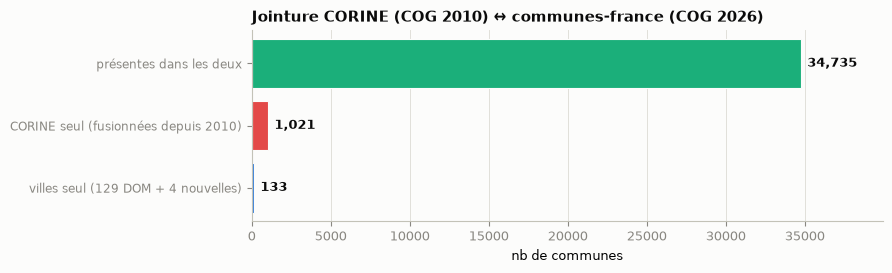


⚠️  LA CLÉ N'EST PAS DANS LE MÊME MILLÉSIME DE COG
   CORINE est en cog_commune_2010, communes-france en COG 2026.
   34,735 communes communes (99.6% du référentiel villes)
   1,021 codes CORINE disparus  → communes fusionnées depuis 2010
   133 codes villes absents   → dont 129 DOM (CORINE = métropole seule)
                                          et 4 communes nouvelles


In [6]:
"""FIG 3 — profil communal  ·  FIG 4 — le piège de la clé de jointure."""
DER = CLC_N[CLC_N.ANNEE == CLC_N.ANNEE.max()].set_index("NUM_COM")
surf = DER[POSTES].sum(axis=1)
pc = pd.DataFrame({
    "surf_ha":  surf,
    "p_foret":  DER[["CLC_311", "CLC_312", "CLC_313"]].sum(axis=1) / surf * 100,
    "p_comb":   DER[COMB].sum(axis=1) / surf * 100,
    "p_maquis": DER["CLC_323"] / surf * 100,
    "p_agri":   DER[[c for c in POSTES if c.startswith("CLC_2")]].sum(axis=1) / surf * 100,
    "p_artif":  DER[[c for c in POSTES if c.startswith("CLC_1")]].sum(axis=1) / surf * 100,
})
pc["dep"] = pc.index.str[:2]

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

for col, c, lab in [("p_foret", VERT, "forêt (31x)"), ("p_agri", "#eda100", "agricole (2xx)"),
                    ("p_artif", "#c3c2b7", "artificialisé (1xx)")]:
    ax[0].hist(pc[col], bins=50, color=c, alpha=.62, label=lab, edgecolor="none")
ax[0].set_title("Part du territoire communal", fontsize=10.5, weight="bold", loc="left")
ax[0].set_xlabel("% de la surface communale"); ax[0].set_ylabel("nb de communes")
ax[0].legend(frameon=False, fontsize=8.5)

# composition du combustible : méditerranéen vs reste — un nuage de points serait
# écrasé, 96 % des communes n'ayant aucun maquis
MEDIT = {"04", "05", "06", "11", "13", "2A", "2B", "30", "34", "48", "66", "83", "84"}
grp = DER.assign(medit=DER.index.str[:2].isin(MEDIT)).groupby("medit")[COMB].sum()
grp = grp.div(grp.sum(axis=1), axis=0) * 100
bas = np.zeros(2)
PAL = {"CLC_311": "#1baf7a", "CLC_312": "#0f6e56", "CLC_313": "#5dcaa5",
       "CLC_321": "#eda100", "CLC_322": "#eb6834", "CLC_323": "#e34948",
       "CLC_324": "#f0997b", "CLC_333": "#c3c2b7"}
for c in COMB:
    ax[1].barh(["reste", "méditerr."], grp[c].values, left=bas, color=PAL[c],
               edgecolor="#fcfcfb", linewidth=1, label=c.split("_")[1])
    for i, v in enumerate(grp[c].values):
        if v > 6:
            ax[1].text(bas[i] + v / 2, i, f"{v:.0f}", ha="center", va="center",
                       fontsize=8, color="#fcfcfb", weight="bold")
    bas += grp[c].values
ax[1].set_title("Composition du combustible", fontsize=10.5, weight="bold", loc="left")
ax[1].set_xlabel("% du combustible communal")
ax[1].legend(frameon=False, fontsize=7, ncol=4, loc="upper center", bbox_to_anchor=(.5, -.22))

# les départements les plus « maquis » — ils dessinent le périmètre méditerranéen
tm = pc.groupby("dep").apply(
    lambda g: 100 * DER.loc[g.index, "CLC_323"].sum() / g.surf_ha.sum(), include_groups=False
).nlargest(12).sort_values()
ax[2].barh(tm.index, tm.values, color=ORANGE, edgecolor="#fcfcfb", linewidth=.8)
ax[2].set_title("Départements les plus « maquis »", fontsize=10.5, weight="bold", loc="left")
ax[2].set_xlabel("% du territoire en poste 323")

for a in ax:
    a.grid(color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
plt.tight_layout(); plt.show()

print(f"Communes 100 % agricoles : {(pc.p_agri > 99).sum():,}")
print(f"Communes sans aucune forêt : {(pc.p_foret == 0).sum():,}")
print(f"Communes à plus de 50 % de forêt : {(pc.p_foret > 50).sum():,}")
print(f"Communes avec du maquis (323 > 0) : {(pc.p_maquis > 0).sum():,} "
      f"({(pc.p_maquis > 0).mean():.1%})  → le poste est bien régional")

# ── FIG 4 : la clé de jointure ──
VILLES = _trouve("data/ville-france/communes-france-2026.csv")
vil = pd.read_csv(VILLES, usecols=["code_insee", "nom_standard", "dep_code"],
                  dtype={"code_insee": str, "dep_code": str})
C, V = set(DER.index), set(vil.code_insee)
inter, c_seul, v_seul = C & V, C - V, V - C
dom = {c for c in v_seul if c.startswith(("971", "972", "973", "974", "976"))}

# 3 barres séparées : en barre empilée, les petits segments débordaient
fig, ax = plt.subplots(figsize=(9, 2.8))
lignes_j = [(f"villes seul ({len(dom)} DOM + {len(v_seul)-len(dom)} nouvelles)", len(v_seul), BLEU),
            ("CORINE seul (fusionnées depuis 2010)", len(c_seul), ROUGE),
            ("présentes dans les deux", len(inter), VERT)]
ax.barh([l[0] for l in lignes_j], [l[1] for l in lignes_j],
        color=[l[2] for l in lignes_j], edgecolor="#fcfcfb", linewidth=.8)
for i, (_, n, _) in enumerate(lignes_j):
    ax.text(n + len(inter) * .012, i, f"{n:,}", va="center", fontsize=9, weight="bold")
ax.set_xlabel("nb de communes"); ax.set_xlim(0, len(inter) * 1.15)
ax.set_title("Jointure CORINE (COG 2010) ↔ communes-france (COG 2026)",
             fontsize=11, weight="bold", loc="left")
ax.grid(axis="x", color=GRID, lw=.7); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False); ax.tick_params(colors=MUTED)
ax.tick_params(axis="y", labelsize=8.5)
plt.tight_layout(); plt.show()

print(f"\n⚠️  LA CLÉ N'EST PAS DANS LE MÊME MILLÉSIME DE COG")
print(f"   CORINE est en cog_commune_2010, communes-france en COG 2026.")
print(f"   {len(inter):,} communes communes ({len(inter)/len(V):.1%} du référentiel villes)")
print(f"   {len(c_seul):,} codes CORINE disparus  → communes fusionnées depuis 2010")
print(f"   {len(v_seul):,} codes villes absents   → dont {len(dom)} DOM (CORINE = métropole seule)")
print(f"                                          et {len(v_seul)-len(dom)} communes nouvelles")

## 6. Synthèse

### Ce qui est établi

| Point | Résultat |
|---|---|
| Volume | 286 048 lignes = 35 756 communes × 8 couples (année, base) |
| Millésimes | 1990, 2000, 2006, 2012, 2018 |
| **Versions doubles** | 2000, 2006, 2012 ont une version « révisée » qui diffère pour **60 à 78 %** des communes |
| Choix retenu | on garde la **révisée** quand elle existe → 178 780 lignes |
| Intégrité | somme des 44 postes = superficie communale, **stable au centième d'hectare** entre millésimes |
| Manquants | **aucun** — un poste absent vaut 0, pas NaN |
| **Clé de jointure** | **COG 2010** ≠ COG 2026 du référentiel communes |
| Recouvrement | 34 735 communes communes (99,6 %), 1 021 codes CORINE périmés, 129 DOM absents |

### Points d'attention pour la suite

1. **La jointure perd 1 021 communes CORINE** fusionnées depuis 2010. Pour un modèle en COG récent, il faudra soit une table de passage COG, soit accepter la perte (0,4 %).
2. **CORINE couvre la métropole seule** — cohérent avec notre périmètre, mais à écrire.
3. **Millésime ≠ année de feu.** Le millésime le plus proche doit être apparié à chaque année de feu, sans jamais utiliser un millésime postérieur à la date prédite (fuite temporelle).
4. Les postes sont en **hectares absolus** : les convertir en **part de la surface communale** avant d'en faire des features, sinon on encode la taille de la commune.